# CBOW STEP-BY-STEP SIMULATION

Example sentence: "I am a beginner in LLM and I hope to master it"

Target word: "beginner"

Context window = 2

Context words: ["am", "a", "in", "LLM"]

In [8]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\srividhya.sundaram\AppData\Local\Programs\Python\Python312\python.exe
3.12.7 (tags/v3.12.7:0b05ead, Oct  1 2024, 03:06:41) [MSC v.1941 64 bit (AMD64)]


In [9]:
import numpy as np
import pandas as pd

np.set_printoptions(precision=4, suppress=True)

step1:Define the Vocab

In [10]:
sentence = "I am a beginner in LLM and I hope to master it"

tokens = sentence.split()
vocabulary = list(dict.fromkeys(tokens))  # preserves order

V = len(vocabulary)          # Vocabulary size
N = 3                        # Embedding dimension

word_to_index = {word: i for i, word in enumerate(vocabulary)}
index_to_word = {i: word for i, word in enumerate(vocabulary)}

print("STEP 1: Vocabulary")
print("Vocabulary:", vocabulary)
print("Vocabulary size V =", V)
print("Embedding dimension N =", N)

STEP 1: Vocabulary
Vocabulary: ['I', 'am', 'a', 'beginner', 'in', 'LLM', 'and', 'hope', 'to', 'master', 'it']
Vocabulary size V = 11
Embedding dimension N = 3


# STEP 2: Define sentence and training example

In [11]:
def get_context_words(vocabulary, target_word, window_size=2):
    """
    Returns context words for a given target word using a symmetric window.

    Parameters:
        vocabulary (list): List of words
        target_word (str): Word for which context is needed
        window_size (int): Number of words to consider on each side

    Returns:
        list: Context words
    """
    context_words = []

    # Find index of target word
    target_index = vocabulary.index(target_word)

    # Define window boundaries
    start = max(0, target_index - window_size)
    end = min(len(vocabulary), target_index + window_size + 1)

    # Collect context words (excluding target itself)
    for i in range(start, end):
        if i != target_index:
            context_words.append(vocabulary[i])

    return context_words

target_word = "beginner"
context_words = get_context_words(vocabulary, target_word, window_size=2)

print("STEP 2: Training Example")
print("Sentence:", sentence)
print("Target word:", target_word)
print("Context words:", context_words)

STEP 2: Training Example
Sentence: I am a beginner in LLM and I hope to master it
Target word: beginner
Context words: ['am', 'a', 'in', 'LLM']


# STEP 3: One-hot encoding function

In [12]:
def one_hot(word, vocab_size, mapping):
    vec = np.zeros(vocab_size)
    vec[mapping[word]] = 1
    return vec

context_one_hot = {word: one_hot(word, V, word_to_index) for word in context_words}
target_one_hot = one_hot(target_word, V, word_to_index)

print("STEP 3: One-Hot Encodings")
for word in context_words:
    print(f"{word:>7} -> {context_one_hot[word]}")
print(f"{target_word:>7} -> {target_one_hot}  (target)")

STEP 3: One-Hot Encodings
     am -> [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
      a -> [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
     in -> [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
    LLM -> [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
beginner -> [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]  (target)


# STEP 4: Initialize CBOW weight matrices
## W  : input-to-hidden  (V x N)
## W' : hidden-to-output (N x V)

In [13]:
W = np.random.randn(V, N) * 0.01
W_prime = np.random.randn(N, V) * 0.01

print("STEP 4: Weight Matrices")
print("W shape:", W.shape, " (input-to-hidden)")
print(pd.DataFrame(W, index=vocabulary, columns=[f"e{i+1}" for i in range(N)]))
print()
print("W' shape:", W_prime.shape, " (hidden-to-output)")
print(pd.DataFrame(W_prime, index=[f"e{i+1}" for i in range(N)], columns=vocabulary))

STEP 4: Weight Matrices
W shape: (11, 3)  (input-to-hidden)
                e1        e2        e3
I        -0.012085  0.016701  0.008934
am        0.003772 -0.006234 -0.008340
a        -0.005317 -0.028272 -0.007100
beginner  0.017751  0.010786 -0.007298
in       -0.006342  0.020814  0.002183
LLM      -0.009058  0.006883 -0.011867
and       0.002536  0.006575 -0.009478
hope     -0.005030  0.005889 -0.002839
to        0.007866  0.011558 -0.013548
master   -0.015785  0.015033  0.009423
it       -0.001711 -0.008246 -0.001393

W' shape: (3, 11)  (hidden-to-output)
           I        am         a  beginner        in       LLM       and  \
e1 -0.001921 -0.019459 -0.003319 -0.008721 -0.008435  0.008750 -0.014502   
e2  0.013145  0.005803  0.008045 -0.011867  0.014161  0.004131  0.004351   
e3  0.007825  0.009982 -0.002596  0.010015  0.014042  0.004830  0.014713   

        hope        to    master        it  
e1 -0.004609 -0.009313  0.007453  0.005207  
e2 -0.009462 -0.006959  0.001975  0.00

# STEP 5: Lookup embeddings for context words
## One-hot(word) @ W = embedding(word)

In Python, the @ operator represents matrix multiplication. While this may initially sound like a purely mathematical operation, in the context of CBOW and word embeddings, it has a very intuitive interpretation.

When we represent a word using one-hot encoding, we create a vector where only one position is “1”, and all others are “0.” This vector is then multiplied by the weight matrix W, which contains the embeddings for all words in the vocabulary. Mathematically, this is written as:

one-hot(word) @ W

This multiplication produces a new vector, which is the embedding of the word.

However, the key idea is simpler than it appears. Because the one-hot vector contains a single “1,” the matrix multiplication effectively selects the corresponding row from the matrix W. All other rows are multiplied by zero and disappear. As a result, the operation does not compute a complex transformation; it simply retrieves the embedding associated with that word.

In other words, the @ operator performs matrix multiplication, but in this specific case, it acts as a lookup mechanism. The weight matrix W can be thought of as a table where each row stores the embedding of a word, and the one-hot vector acts as a pointer that selects the correct row.

This is an important conceptual shift. Instead of thinking of embeddings as something computed from scratch, we should think of them as values stored in the model and accessed through this operation. Over the course of training, these stored values are updated so that words that appear in similar contexts develop similar embeddings.

In [14]:
context_embeddings = {}
for word in context_words:
    context_embeddings[word] = context_one_hot[word] @ W

print("STEP 5: Context Word Embeddings")
for word in context_words:
    print(f"{word:>7} -> {context_embeddings[word]}")

STEP 5: Context Word Embeddings
     am -> [ 0.0038 -0.0062 -0.0083]
      a -> [-0.0053 -0.0283 -0.0071]
     in -> [-0.0063  0.0208  0.0022]
    LLM -> [-0.0091  0.0069 -0.0119]


# STEP 6: Aggregate context embeddings
## CBOW uses average (or sum)

In [15]:
embedding_matrix = np.vstack([context_embeddings[word] for word in context_words])
hidden_vector = embedding_matrix.mean(axis=0)

print("STEP 6: Aggregate Context Embeddings")
print("Embedding matrix:")
print(pd.DataFrame(embedding_matrix, index=context_words, columns=[f"e{i+1}" for i in range(N)]))
print()
print("Sum of context embeddings   =", embedding_matrix.sum(axis=0))
print("Average hidden vector h     =", hidden_vector)

STEP 6: Aggregate Context Embeddings
Embedding matrix:
           e1        e2        e3
am   0.003772 -0.006234 -0.008340
a   -0.005317 -0.028272 -0.007100
in  -0.006342  0.020814  0.002183
LLM -0.009058  0.006883 -0.011867

Sum of context embeddings   = [-0.0169 -0.0068 -0.0251]
Average hidden vector h     = [-0.0042 -0.0017 -0.0063]


# STEP 7: Compute output scores
## h @ W' gives one score per vocabulary word

In [16]:
scores = hidden_vector @ W_prime

print("STEP 7: Output Scores (Before Softmax)")
score_df = pd.DataFrame({
    "Word": vocabulary,
    "Score": scores
})
print(score_df)

STEP 7: Output Scores (Before Softmax)
        Word     Score
0          I -0.000063
1         am  0.000010
2          a  0.000017
3   beginner -0.000006
4         in -0.000077
5        LLM -0.000074
6        and -0.000038
7       hope -0.000031
8         to  0.000050
9     master -0.000040
10        it -0.000055


# STEP 8: Softmax function
## Converts scores into probabilities

In [17]:
def softmax(x):
    shifted = x - np.max(x)          # for numerical stability
    exp_x = np.exp(shifted)
    return exp_x / np.sum(exp_x)

probabilities = softmax(scores)

print("STEP 8: Softmax Probabilities")
prob_df = pd.DataFrame({
    "Word": vocabulary,
    "Probability": probabilities
}).sort_values(by="Probability", ascending=False).reset_index(drop=True)
print(prob_df)

STEP 8: Softmax Probabilities
        Word  Probability
0         to     0.090916
1          a     0.090913
2         am     0.090913
3   beginner     0.090911
4       hope     0.090909
5        and     0.090908
6     master     0.090908
7         it     0.090907
8          I     0.090906
9        LLM     0.090905
10        in     0.090905


# STEP 9: Predicted word

In [15]:
predicted_index = np.argmax(probabilities)
predicted_word = index_to_word[predicted_index]

print("STEP 9: Prediction")
print("Predicted word =", predicted_word)
print("Actual target  =", target_word)

STEP 9: Prediction
Predicted word = I
Actual target  = beginner


# STEP 10: Cross-entropy loss
## For one training example

In [16]:
target_index = word_to_index[target_word]
loss = -np.log(probabilities[target_index])

print("STEP 10: Cross-Entropy Loss")
print(f"Target probability for '{target_word}' = {probabilities[target_index]:.6f}")
print(f"Loss = -log(P(target|context)) = {loss:.6f}")

STEP 10: Cross-Entropy Loss
Target probability for 'beginner' = 0.090915
Loss = -log(P(target|context)) = 2.397828


# STEP 11: Compact summary

In [17]:
print("FINAL SUMMARY")
print(f"Context words: {context_words}")
print(f"Hidden vector: {hidden_vector}")
print(f"Predicted word: {predicted_word}")
print(f"Actual target:  {target_word}")
print(f"Loss: {loss:.6f}")

FINAL SUMMARY
Context words: ['am', 'a', 'in', 'LLM']
Hidden vector: [-0.0048  0.0064  0.004 ]
Predicted word: I
Actual target:  beginner
Loss: 2.397828


# Show the top-k predictions


In [18]:
k = 5
print(f"Top {k} predicted words:")
print(prob_df.head(k))

Top 5 predicted words:
       Word  Probability
0         I     0.090921
1        it     0.090921
2  beginner     0.090915
3       and     0.090913
4       LLM     0.090912


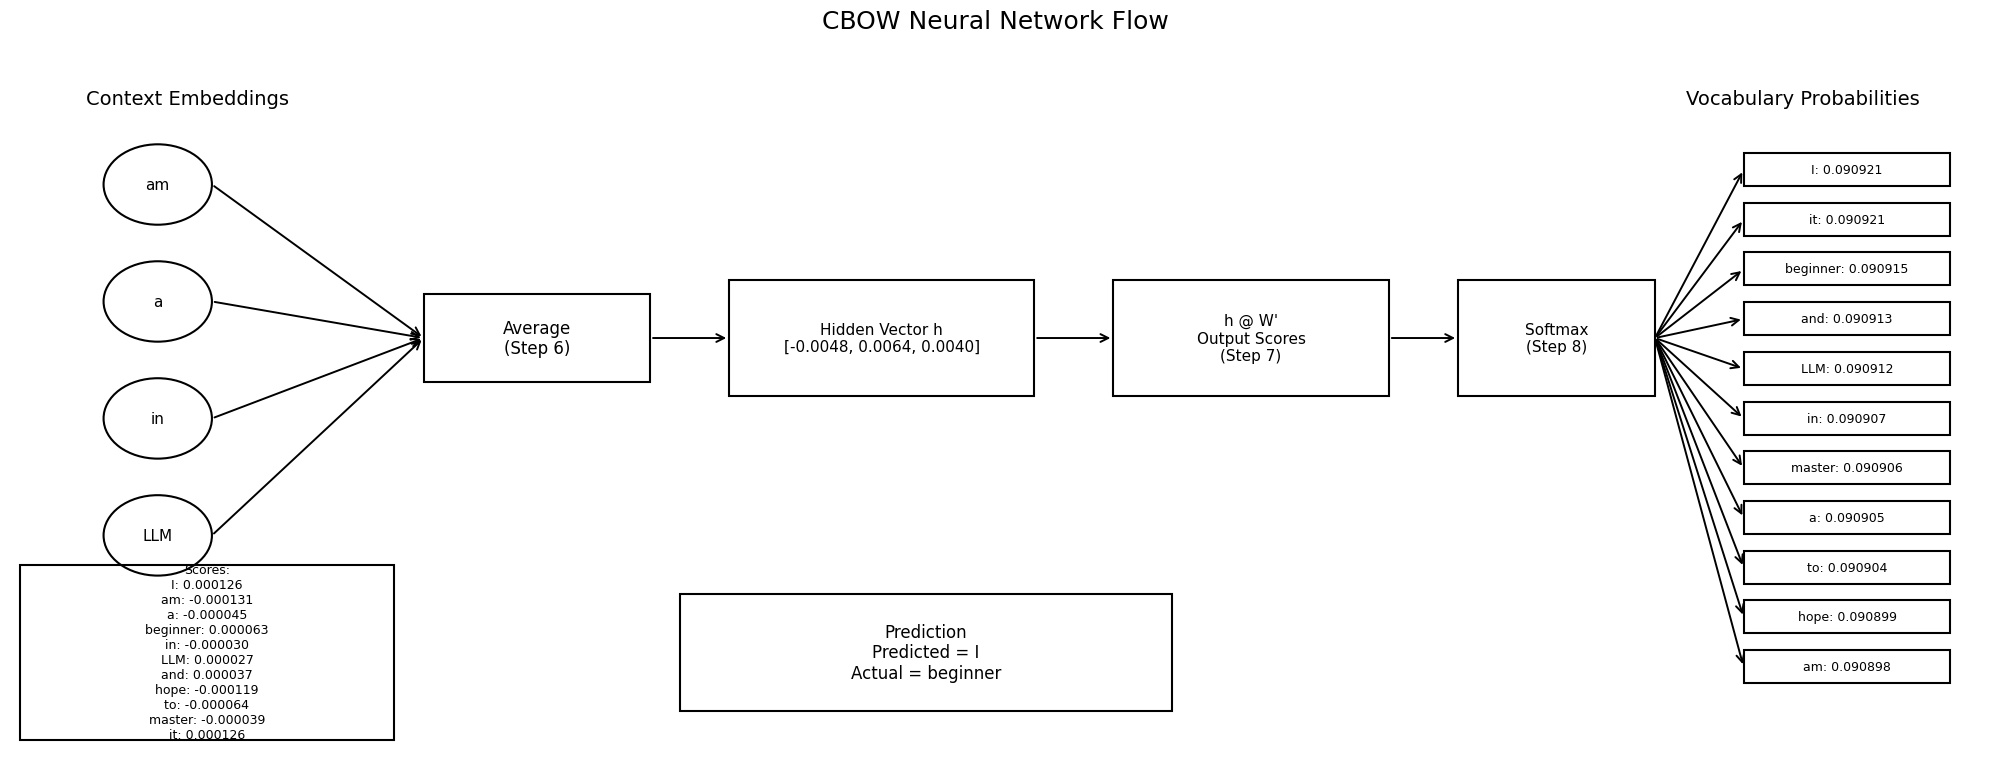

In [19]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Rectangle
import numpy as np

# ------------------------------------------------------------
# Example values from the CBOW simulation
# ------------------------------------------------------------
actual_target = target_word

# scores is already a numeric array from Step 7
score_values = np.array(scores, dtype=float)
probability_values = softmax(score_values)

scores_dict = dict(zip(vocabulary, score_values))
probabilities_dict = dict(zip(vocabulary, probability_values))
predicted_word = vocabulary[np.argmax(probability_values)]

# ------------------------------------------------------------
# Drawing helper functions
# ------------------------------------------------------------
def draw_node(ax, x, y, text, radius=0.42, fontsize=10):
    circle = Circle((x, y), radius, fill=False, linewidth=1.5)
    ax.add_patch(circle)
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize)

def draw_box(ax, x, y, w, h, text, fontsize=10):
    rect = Rectangle((x, y), w, h, fill=False, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fontsize)

def draw_arrow(ax, x1, y1, x2, y2):
    arrow = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle="->",
        mutation_scale=14,
        linewidth=1.4
    )
    ax.add_patch(arrow)

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(20, 8))
ax.set_xlim(0, 20)
ax.set_ylim(0, 10)
ax.axis("off")

fig.suptitle("CBOW Neural Network Flow", fontsize=18, y=0.96)

# ------------------------------------------------------------
# Context embeddings
# ------------------------------------------------------------
ax.text(1.8, 9.0, "Context Embeddings", fontsize=14, ha="center")

y_positions = [7.9, 6.3, 4.7, 3.1]
for word, y in zip(context_words, y_positions):
    draw_node(ax, 1.5, y, word, radius=0.55, fontsize=11)

# ------------------------------------------------------------
# Average block (compact)
# ------------------------------------------------------------
draw_box(ax, 4.2, 5.2, 2.3, 1.2, "Average\n(Step 6)", fontsize=12)

for y in y_positions:
    draw_arrow(ax, 2.05, y, 4.2, 5.8)

# ------------------------------------------------------------
# Hidden vector block (compact)
# ------------------------------------------------------------
draw_box(
    ax, 7.3, 5.0, 3.1, 1.6,
    f"Hidden Vector h\n[{hidden_vector[0]:.4f}, {hidden_vector[1]:.4f}, {hidden_vector[2]:.4f}]",
    fontsize=11
)
draw_arrow(ax, 6.5, 5.8, 7.3, 5.8)

# ------------------------------------------------------------
# Output scores block (narrow)
# ------------------------------------------------------------
draw_box(
    ax, 11.2, 5.0, 2.8, 1.6,
    "h @ W'\nOutput Scores\n(Step 7)",
    fontsize=11
)
draw_arrow(ax, 10.4, 5.8, 11.2, 5.8)

# ------------------------------------------------------------
# Softmax block (narrow)
# ------------------------------------------------------------
draw_box(
    ax, 14.7, 5.0, 2.0, 1.6,
    "Softmax\n(Step 8)",
    fontsize=11
)
draw_arrow(ax, 14.0, 5.8, 14.7, 5.8)

# ------------------------------------------------------------
# Vocabulary probabilities
# ------------------------------------------------------------
ax.text(18.2, 9.0, "Vocabulary Probabilities", fontsize=14, ha="center")

sorted_probs = sorted(
    [(word, float(probabilities_dict[word])) for word in vocabulary],
    key=lambda x: x[1],
    reverse=True
)
prob_y = np.linspace(8.1, 1.3, len(sorted_probs))

for (word, prob), y in zip(sorted_probs, prob_y):
    label = f"{word}: {prob:.6f}"
    draw_box(ax, 17.6, y - 0.22, 2.1, 0.45, label, fontsize=9)
    draw_arrow(ax, 16.7, 5.8, 17.6, y)

# ------------------------------------------------------------
# Score panel (smaller)
# ------------------------------------------------------------
score_text = "Scores:\n" + "\n".join([f"{w}: {scores_dict[w]:.6f}" for w in vocabulary])
draw_box(ax, 0.1, 0.3, 3.8, 2.4, score_text, fontsize=9)

# ------------------------------------------------------------
# Prediction block (smaller)
# ------------------------------------------------------------
# predicted_word = max(probabilities_dict, key=probabilities_dict.get)

draw_box(
    ax, 6.8, 0.7, 5.0, 1.6,
    f"Prediction\nPredicted = {predicted_word}\nActual = {actual_target}",
    fontsize=12
)

plt.tight_layout()
plt.show()